In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

In [61]:
df = pd.read_csv('data.csv')
df.head()

,process.b1.capacity,process.b2.capacity,process.b3.capacity,process.b4.capacity,property.price,property.product,property.winner,verification.result,verification.time
0,0,0,2,1,59,1,0,False,163.316667
1,0,0,2,1,59,2,0,False,200.860000
2,0,0,2,1,59,4,0,False,154.888889
3,0,0,2,1,59,6,0,False,108.640000
4,0,0,2,1,60,1,0,True,85.466667


In [62]:
print("NA:")
print(df.isna().sum())
print("Null:")
print(df.isnull().sum())

NA:
process.b1.capacity    0
process.b2.capacity    0
process.b3.capacity    0
process.b4.capacity    0
property.price         0
property.product       0
property.winner        0
verification.result    0
verification.time      0
dtype: int64
Null:
process.b1.capacity    0
process.b2.capacity    0
process.b3.capacity    0
process.b4.capacity    0
property.price         0
property.product       0
property.winner        0
verification.result    0
verification.time      0
dtype: int64


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   process.b1.capacity  2043 non-null   int64  
 1   process.b2.capacity  2043 non-null   int64  
 2   process.b3.capacity  2043 non-null   int64  
 3   process.b4.capacity  2043 non-null   int64  
 4   property.price       2043 non-null   int64  
 5   property.product     2043 non-null   int64  
 6   property.winner      2043 non-null   int64  
 7   verification.result  2043 non-null   bool   
 8   verification.time    2043 non-null   float64
dtypes: bool(1), float64(1), int64(7)
memory usage: 129.8 KB


In [64]:
df = df.drop('verification.time', axis=1)

В датасеті нема пропущенних данних та усі фічі ― цілі числа

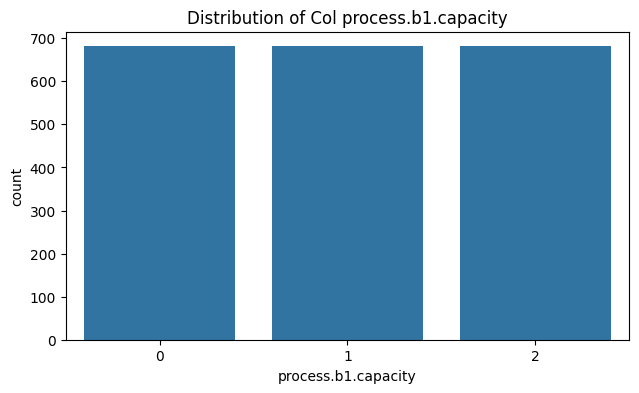

count    2043.000000
mean        1.000000
std         0.816696
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         2.000000
Name: process.b1.capacity, dtype: float64


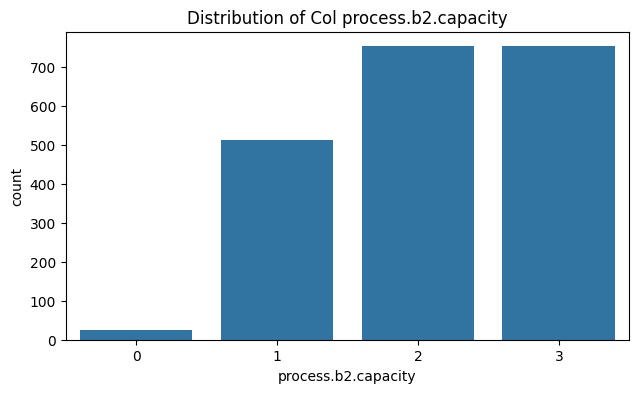

count    2043.000000
mean        2.093979
std         0.811269
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: process.b2.capacity, dtype: float64


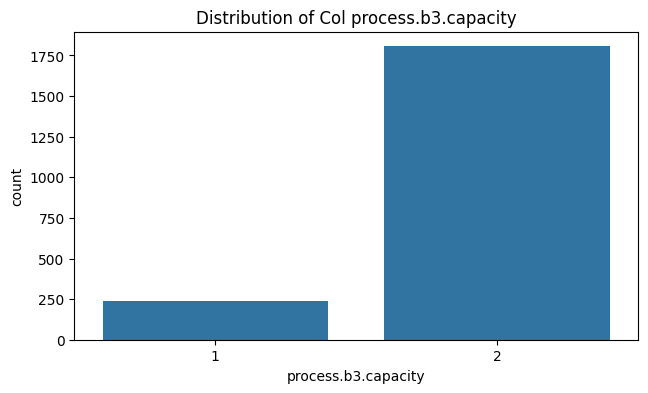

count    2043.000000
mean        1.883994
std         0.320310
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         2.000000
Name: process.b3.capacity, dtype: float64


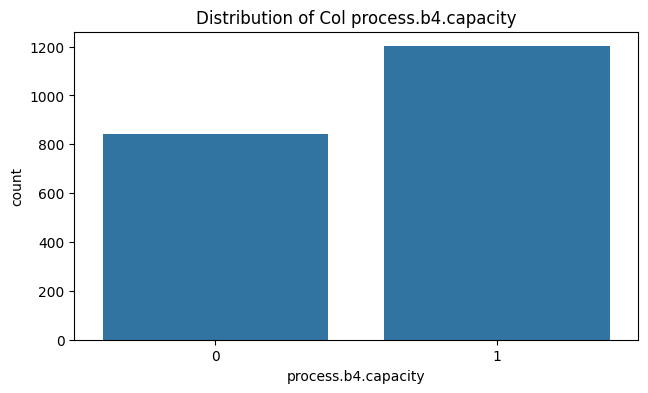

count    2043.000000
mean        0.587861
std         0.492340
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: process.b4.capacity, dtype: float64


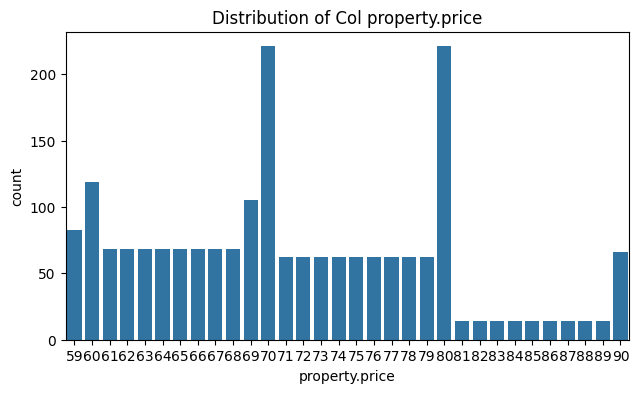

count    2043.000000
mean       71.473324
std         8.048740
min        59.000000
25%        65.000000
50%        70.000000
75%        78.000000
max        90.000000
Name: property.price, dtype: float64


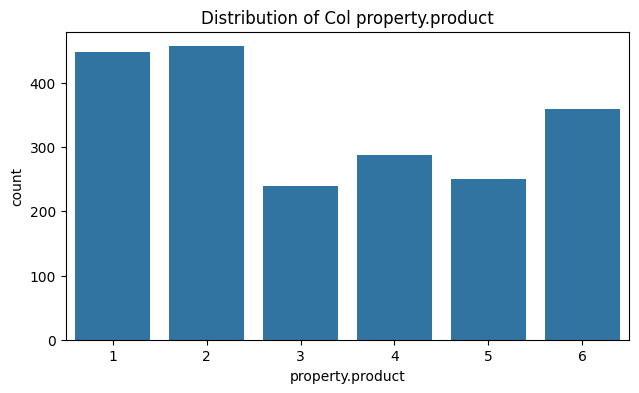

count    2043.000000
mean        3.252080
std         1.804225
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max         6.000000
Name: property.product, dtype: float64


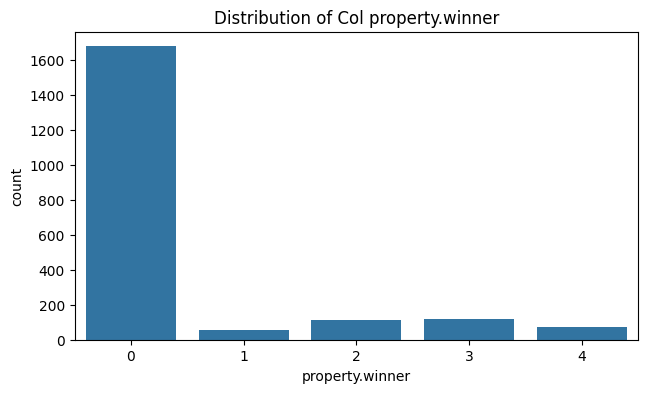

count    2043.000000
mean        0.455213
std         1.062828
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.000000
Name: property.winner, dtype: float64


In [65]:
cols = ('process.b1.capacity', 'process.b2.capacity', 'process.b3.capacity',
       'process.b4.capacity', 'property.price', 'property.product', 'property.winner')

for col in cols:
    plt.figure(figsize=(16, 4))
    
    # Будуємо гістограми
    plt.subplot(1, 2, 1)
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of Col {col}')
    
    plt.show()
    print(df[col].describe())

У загальному викидів немає, данні більш менш рівномірні. Вірогідно property.winner та property.product це класифікації, тому буду їх пропускати через OneHotEncoder

Дадам 2 фічі: загальна вмісткість та ціна за вмісткість

In [66]:
df['total_capacity'] = (df['process.b1.capacity'] + df['process.b2.capacity'] + df['process.b3.capacity'] + df['process.b4.capacity'])

df['price_per_capacity'] = df['property.price'] / (df['total_capacity'] + 1e-5)

Почну підготовку данних (Енкодер + масштабування)

In [67]:
target = 'verification.result'
X = df.drop(target, axis=1)
y = df[target]

cat_cols = ['property.product', 'property.winner']
num_cols = X.drop(cat_cols, axis=1).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

Поділ датасету на тренувальну, тестову частину. Потім буду використовувати кросс-валідацію 

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Bagging

In [85]:
bagging_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

Підбір гіперпараметрів

In [90]:
param_grid_bagging = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search_bagging = GridSearchCV(
    estimator=bagging_pipeline,
    param_grid=param_grid_bagging,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_bagging.fit(X_train, y_train)

bagging_model = grid_search_bagging.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Boosting за допомогою XGBoost

In [81]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

Підбір гіперпараметрів

In [89]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],    
    'classifier__max_depth': [3, 5, 7],              
    'classifier__learning_rate': [0.01, 0.1, 0.2]    
}

grid_search_boosting = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_boosting.fit(X_train, y_train)

boosting_model = grid_search_boosting.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Stacking

In [91]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
    ('ridge', RidgeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

stacking_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', stacking_clf)
])

stacking_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Тренування та предікшн моделей

In [92]:
models = {
    "Bagging": bagging_model,
    "Boosting": boosting_model,
    "Stacking": stacking_model
}

results = {}

for name, model in models.items():
    y_pred_test = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_test)
    print(f"\n{name} Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred_test))


Bagging Test Accuracy: 0.9886
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       534
        True       1.00      0.91      0.95        79

    accuracy                           0.99       613
   macro avg       0.99      0.96      0.97       613
weighted avg       0.99      0.99      0.99       613


Boosting Test Accuracy: 0.9967
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       534
        True       1.00      0.97      0.99        79

    accuracy                           1.00       613
   macro avg       1.00      0.99      0.99       613
weighted avg       1.00      1.00      1.00       613


Stacking Test Accuracy: 0.9723
              precision    recall  f1-score   support

       False       0.98      0.99      0.98       534
        True       0.93      0.85      0.89        79

    accuracy                           0.97       613
   macro avg       0.95      0.92

Результати нам кажуть, що найкраще передбачення зробив Boosting через XGBoost, далі Bagging, а далі Stacking (KNeighbors, Ridge, RandomForest).

В цьому ж порядку займав час тренування від більшого до меншого. Можливо Stacking міг би більш точно передбачитти, якщо я додав би туди інші моделі, але все одно результат дуже хороший